# Run 2 — Artifact Removal

**Research question (Q1):** *Does removing non-anatomical artifacts (e.g. the marker letter 'R') from chest X-rays improve pneumonia classification performance?*

This notebook **imports the CNN trained in Run 1** (`CNN.pkl`) and runs an
**inference-time ablation**: the *same* model is evaluated on the *same* held-out
test set twice —

1. on the raw images (artifacts present), and
2. on the same images after letter/marker artifacts have been detected and inpainted.

If the metrics improve when artifacts are removed, the model was (partly) keying on
those non-anatomical markers. Note this is a quick ablation using the Run-1 model; a
fully rigorous Run 2 would *retrain* on cleaned data — but reusing `CNN.pkl` isolates
the effect of the artifacts at prediction time.

In [1]:
import os
import random
import numpy as np
import torch

BASE = "./chest_xray"
classes = ["NORMAL", "PNEUMONIA"]
SOURCE_SPLITS = ["train", "val", "test"]
IMAGE_EXTS = {".jpg", ".jpeg", ".png"}
BATCH_SIZE = 32
IMG_SIZE = 224

# Same seeds as Run 1 -> identical 80/10/10 split -> identical test set,
# so the comparison is apples-to-apples.
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

# Rebuild the exact same split used in no_letters.ipynb (Run 1).
all_files = {}
for cls in classes:
    relative_paths = []
    for split in SOURCE_SPLITS:
        cls_dir = os.path.join(BASE, split, cls)
        for f in sorted(os.listdir(cls_dir)):
            if os.path.splitext(f)[1].lower() in IMAGE_EXTS:
                relative_paths.append(os.path.join(split, cls, f))
    random.shuffle(relative_paths)
    all_files[cls] = relative_paths

splits_data = {"train": {}, "val": {}, "test": {}}
for cls, files in all_files.items():
    n = len(files)
    n_train = int(n * 0.8)
    n_val   = int(n * 0.1)
    splits_data["train"][cls] = files[:n_train]
    splits_data["val"][cls]   = files[n_train:n_train + n_val]
    splits_data["test"][cls]  = files[n_train + n_val:]

print("Test images:", sum(len(v) for v in splits_data["test"].values()))

Test images: 587


## 1. Device and preprocessing transforms

Identical preprocessing to Run 1's `eval_transform` (no augmentation). The only
difference in Run 2 is an optional letter-removal step inserted *before* this pipeline.

In [2]:
import platform
from PIL import Image, ImageOps
from torchvision import transforms

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using device: CUDA -", torch.cuda.get_device_name(0))
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device: MPS (Apple Silicon)")
else:
    device = torch.device("cpu")
    print("Using device: CPU")

print(f"PyTorch version: {torch.__version__}")


class PadToSquare:
    """Pad to a square (centred) so resizing does not distort the aspect ratio."""
    def __init__(self, fill=0):
        self.fill = fill

    def __call__(self, image):
        width, height = image.size
        if width == height:
            return image
        max_side = max(width, height)
        pad_left = (max_side - width) // 2
        pad_top = (max_side - height) // 2
        padding = (pad_left, pad_top,
                   max_side - width - pad_left,
                   max_side - height - pad_top)
        return ImageOps.expand(image, padding, fill=self.fill)


# Standard evaluation transform (same as Run 1).
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    PadToSquare(fill=0),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

Using device: MPS (Apple Silicon)
PyTorch version: 2.11.0


## 2. Model architecture

`joblib` pickled the *whole* model object in Run 1, so unpickling needs the
`PneumoniaCNN` class to be defined first. This is the exact architecture from
`no_letters.ipynb` — we only define it here, we do **not** retrain.

In [3]:
import torch.nn as nn
import torch.nn.functional as F


class PneumoniaCNN(nn.Module):
    """3-block CNN with batch norm + dropout. Must match the Run-1 definition
    exactly so the pickled weights in CNN.pkl load cleanly."""
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 2),
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

## 3. Import the trained model from `CNN.pkl`

`CNN.pkl` is the model `joblib.dump`-ed at the end of Run 1. The loader below is
robust to a pickle created on a CUDA (NVIDIA) machine being opened on CPU/MPS:
in that case the tensor storages are remapped to CPU before we move the model
onto whatever device this notebook is running on.

In [4]:
import io
import pickle
import joblib

MODEL_PATH = "CNN.pkl"


def load_pickled_model(path):
    """Load a joblib/pickle-saved torch model, remapping CUDA storages to CPU
    if the file was created on an NVIDIA box."""
    try:
        return joblib.load(path)
    except RuntimeError as e:
        if "CUDA" not in str(e):
            raise
        print("CNN.pkl was saved on a CUDA device - remapping storages to CPU.")

        class CPUUnpickler(pickle.Unpickler):
            def find_class(self, module, name):
                if module == "torch.storage" and name == "_load_from_bytes":
                    return lambda b: torch.load(io.BytesIO(b), map_location="cpu")
                return super().find_class(module, name)

        with open(path, "rb") as f:
            return CPUUnpickler(f).load()


model = load_pickled_model(MODEL_PATH)
model = model.to(device)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f"Loaded model from {MODEL_PATH}")
print(f"Type: {type(model).__name__}  |  parameters: {n_params:,}  |  device: {device}")

CNN.pkl was saved on a CUDA device - remapping storages to CPU.
Loaded model from CNN.pkl
Type: PneumoniaCNN  |  parameters: 25,784,578  |  device: mps


## 4. Letter / artifact removal

Marker letters (the orientation 'R'/'L', technician text, etc.) are **bright,
small blobs placed near the image border** — away from the lung fields. We detect
them with OpenCV and inpaint the region so no hard edge is left behind:

1. Threshold the brightest pixels (top percentile).
2. Find connected components.
3. Keep a component as an *artifact* only if it is small, near the border, and has
   a letter-like aspect ratio — this protects bright anatomy in the chest centre.
4. Dilate the mask slightly and `cv2.inpaint` (Telea) to fill it from neighbours.

The function works on a single-channel grayscale array and returns the cleaned
image plus the mask (handy for the visualisation below).

In [6]:
import cv2


def remove_letters(gray,
                   brightness_pct=99.5,
                   min_area=20,
                   max_area_frac=0.012,
                   border_frac=0.18,
                   dilate_px=5):
    """Detect and inpaint bright letter/marker artifacts in a grayscale X-ray.

    gray          : uint8 HxW array
    brightness_pct: percentile used as the 'bright pixel' threshold
    min_area      : ignore blobs smaller than this (noise)
    max_area_frac : ignore blobs larger than this fraction of the image (anatomy)
    border_frac   : a blob counts as an artifact only if its centroid lies within
                    this fraction of the border (markers sit at the edges)
    dilate_px     : grow the mask before inpainting so the blob edge is covered

    Returns (cleaned_uint8, mask_uint8).
    """
    h, w = gray.shape
    thr = max(200, np.percentile(gray, brightness_pct))
    bright = (gray >= thr).astype(np.uint8)

    n, labels, stats, centroids = cv2.connectedComponentsWithStats(bright, connectivity=8)

    mask = np.zeros((h, w), np.uint8)
    max_area = max_area_frac * h * w
    bx, by = border_frac * w, border_frac * h

    for i in range(1, n):  # 0 is the background
        area = stats[i, cv2.CC_STAT_AREA]
        if area < min_area or area > max_area:
            continue
        cx, cy = centroids[i]
        near_border = (cx < bx or cx > w - bx or cy < by or cy > h - by)
        if not near_border:
            continue
        cw = stats[i, cv2.CC_STAT_WIDTH]
        ch = stats[i, cv2.CC_STAT_HEIGHT]
        aspect = cw / max(ch, 1)
        if aspect < 0.15 or aspect > 6.0:   # too thin/wide to be a letter
            continue
        mask[labels == i] = 255

    if mask.any():
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (dilate_px, dilate_px))
        mask = cv2.dilate(mask, kernel)
        cleaned = cv2.inpaint(gray, mask, 3, cv2.INPAINT_TELEA)
    else:
        cleaned = gray

    return cleaned, mask


class RemoveLetters:
    """torchvision-style transform: takes a grayscale ('L') PIL image, returns a
    grayscale PIL image with letter artifacts inpainted. Drop it in as the first
    step of a transform pipeline."""
    def __call__(self, image):
        gray = np.array(image.convert("L"), dtype=np.uint8)
        cleaned, _ = remove_letters(gray)
        return Image.fromarray(cleaned, mode="L")


# Clean transform = letter removal, then the exact same eval pipeline as Run 1.
clean_transform = transforms.Compose([
    RemoveLetters(),
    transforms.Grayscale(num_output_channels=3),
    PadToSquare(fill=0),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

## 5. Visual sanity check

Before trusting the metrics, look at what the artifact remover actually does.
Original | detected mask (red) | inpainted result.

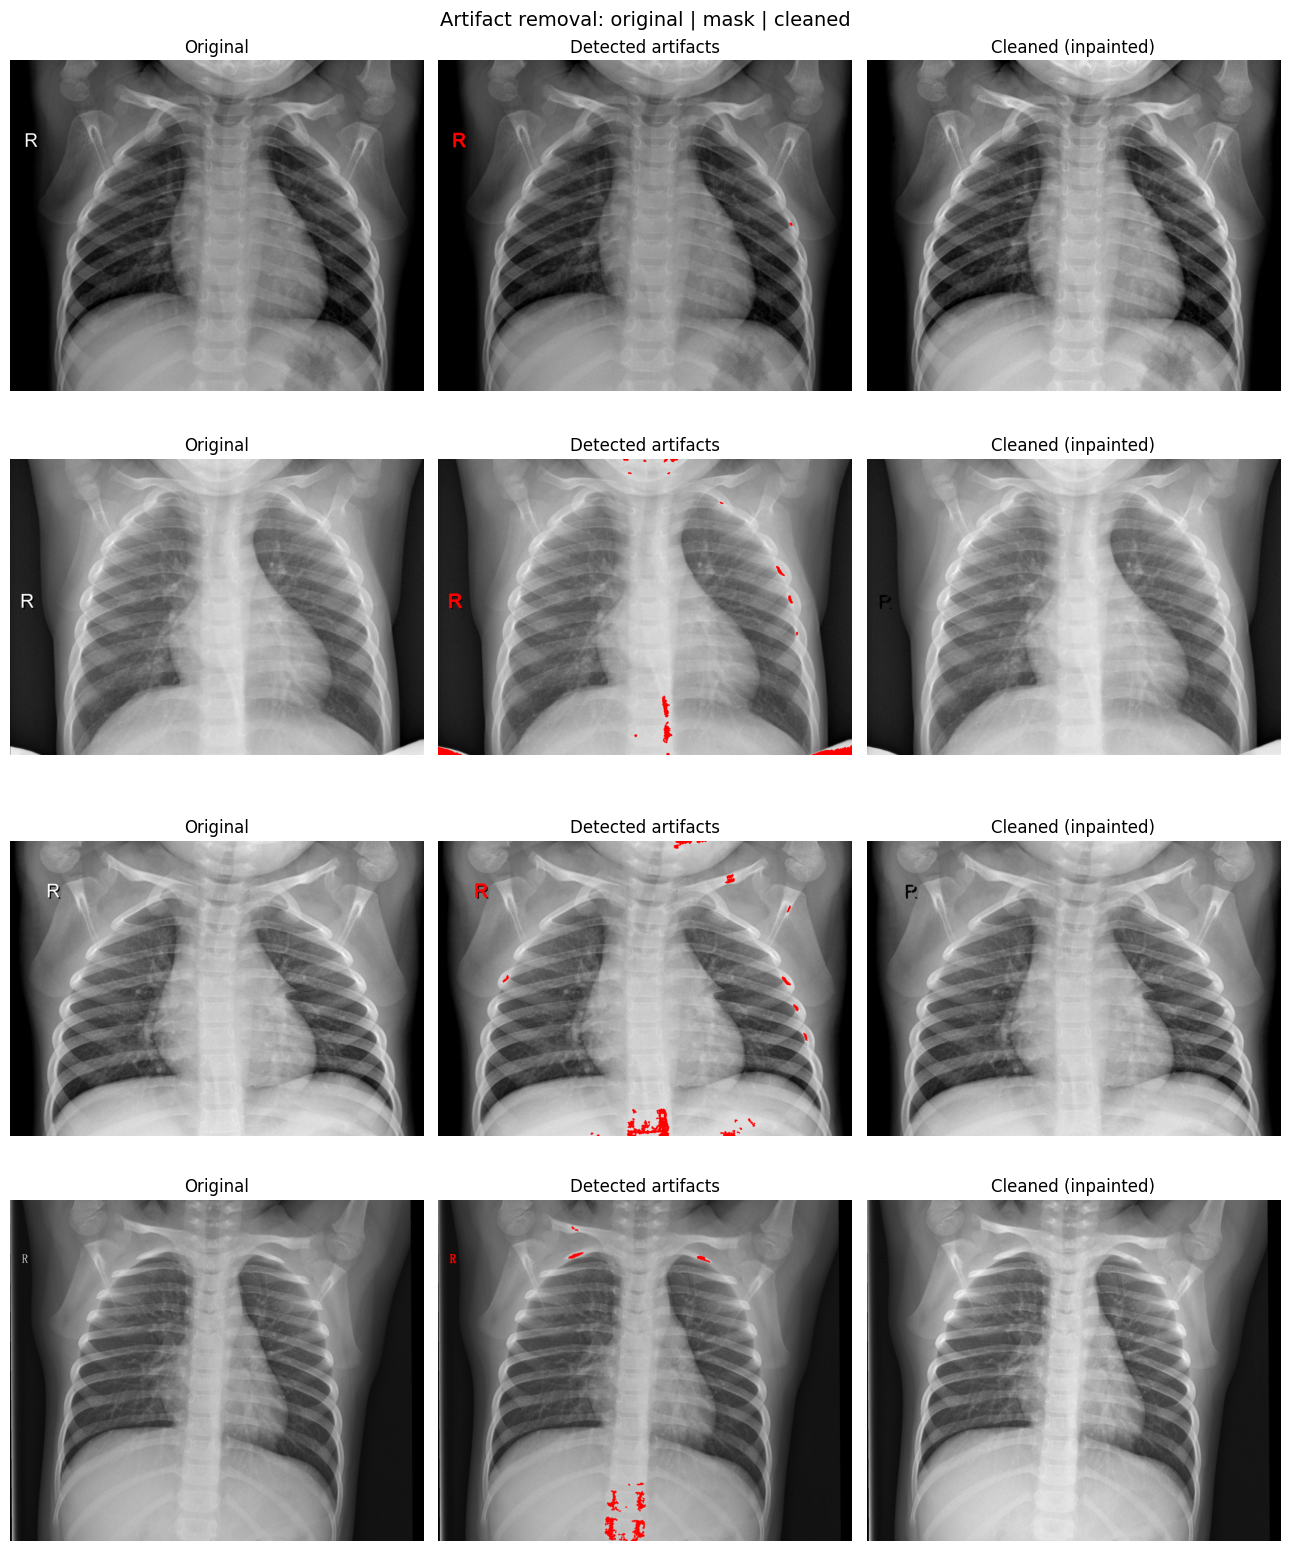

In [7]:
import matplotlib.pyplot as plt

# Pick a few test images that actually contain bright border blobs to show.
sample_paths = []
for cls in classes:
    for rel in splits_data["test"][cls]:
        g = np.array(Image.open(os.path.join(BASE, rel)).convert("L"), dtype=np.uint8)
        _, m = remove_letters(g)
        if m.any():
            sample_paths.append(rel)
        if len(sample_paths) >= 4:
            break
    if len(sample_paths) >= 4:
        break

if not sample_paths:  # fallback: just show the first few test images
    sample_paths = splits_data["test"][classes[0]][:4]

fig, axes = plt.subplots(len(sample_paths), 3, figsize=(13, 4 * len(sample_paths)))
axes = np.atleast_2d(axes)
fig.suptitle("Artifact removal: original | mask | cleaned", fontsize=14)

for row, rel in enumerate(sample_paths):
    gray = np.array(Image.open(os.path.join(BASE, rel)).convert("L"), dtype=np.uint8)
    cleaned, mask = remove_letters(gray)

    overlay = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    overlay[mask > 0] = [255, 0, 0]

    axes[row, 0].imshow(gray, cmap="gray");    axes[row, 0].set_title("Original")
    axes[row, 1].imshow(overlay);               axes[row, 1].set_title("Detected artifacts")
    axes[row, 2].imshow(cleaned, cmap="gray");  axes[row, 2].set_title("Cleaned (inpainted)")
    for col in range(3):
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

## 6. Build the test datasets

The same `Dataset` class as Run 1. We build it twice over the **same** test split:
once with the raw `eval_transform`, once with `clean_transform`.

In [8]:
from torch.utils.data import DataLoader


class ChestXrayCombineClasses(torch.utils.data.Dataset):
    def __init__(self, base_dir, split_files, classes, transform=None):
        self.base_dir = base_dir
        self.transform = transform
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.samples = []
        for class_name in classes:
            label = self.class_to_idx[class_name]
            for relative_path in split_files[class_name]:
                self.samples.append((os.path.join(base_dir, relative_path), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image_path, label = self.samples[index]
        image = Image.open(image_path).convert("L")
        if self.transform is not None:
            image = self.transform(image)
        return image, label


test_dataset_raw = ChestXrayCombineClasses(
    BASE, splits_data["test"], classes, transform=eval_transform)
test_dataset_clean = ChestXrayCombineClasses(
    BASE, splits_data["test"], classes, transform=clean_transform)

# num_workers=0 keeps OpenCV happy across platforms (cv2 + forked workers
# can deadlock); the test set is small so single-threaded loading is fine.
test_loader_raw = DataLoader(test_dataset_raw, batch_size=BATCH_SIZE, shuffle=False)
test_loader_clean = DataLoader(test_dataset_clean, batch_size=BATCH_SIZE, shuffle=False)

print("Test images (raw / clean):",
      len(test_dataset_raw), "/", len(test_dataset_clean))

Test images (raw / clean): 587 / 587


## 7. Evaluate the imported model

`evaluate` runs the loaded `CNN.pkl` model over a loader and returns predictions,
labels and PNEUMONIA probabilities — everything we need for the comparison.

In [9]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, ConfusionMatrixDisplay)


@torch.no_grad()
def evaluate(loader):
    model.eval()
    preds, labels, probs = [], [], []
    for images, batch_labels in loader:
        outputs = model(images.to(device))
        probs.extend(F.softmax(outputs, dim=1)[:, 1].cpu().numpy())
        preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
        labels.extend(batch_labels.numpy())
    return np.array(labels), np.array(preds), np.array(probs)


print("Evaluating on RAW test images (artifacts present)...")
raw_labels, raw_preds, raw_probs = evaluate(test_loader_raw)

print("Evaluating on CLEANED test images (artifacts removed)...")
cln_labels, cln_preds, cln_probs = evaluate(test_loader_clean)

print("Done.")

Evaluating on RAW test images (artifacts present)...
Evaluating on CLEANED test images (artifacts removed)...
Done.


## 8. Results — does removing artifacts help?

Side-by-side confusion matrices, classification reports and AUC. A positive
**delta** means artifact removal improved that metric.

In [ ]:
def metrics(labels, preds, probs):
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
    return {
        "accuracy":  (tp + tn) / (tp + tn + fp + fn),
        "recall":    tp / (tp + fn) if (tp + fn) else 0.0,   # sensitivity
        "precision": tp / (tp + fp) if (tp + fp) else 0.0,
        "auc":       roc_auc_score(labels, probs),
    }


raw_m = metrics(raw_labels, raw_preds, raw_probs)
cln_m = metrics(cln_labels, cln_preds, cln_probs)

# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (title, lbl, prd, cmap) in zip(axes, [
        ("Raw (artifacts present)", raw_labels, raw_preds, "Blues"),
        ("Cleaned (artifacts removed)", cln_labels, cln_preds, "Greens")]):
    cm = confusion_matrix(lbl, prd, labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()

# Metric comparison table
print(f"{'metric':<12}{'raw':>10}{'cleaned':>12}{'delta':>12}")
print("-" * 46)
for k in ["accuracy", "recall", "precision", "auc"]:
    delta = cln_m[k] - raw_m[k]
    print(f"{k:<12}{raw_m[k]:>10.4f}{cln_m[k]:>12.4f}{delta:>+12.4f}")

print("\nRaw classification report:")
print(classification_report(raw_labels, raw_preds, target_names=classes))
print("Cleaned classification report:")
print(classification_report(cln_labels, cln_preds, target_names=classes))

n_changed = int(np.sum(raw_preds != cln_preds))
print(f"Predictions changed by artifact removal: {n_changed} / {len(raw_preds)}")

auc_delta = cln_m['auc'] - raw_m['auc']
if auc_delta > 0:
    print(f"\nArtifact removal IMPROVED test AUC by {auc_delta:+.4f}.")
elif auc_delta < 0:
    print(f"\nArtifact removal REDUCED test AUC by {auc_delta:+.4f}.")
else:
    print("\nArtifact removal left test AUC unchanged.")